In [87]:
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path
from scipy.spatial.distance import squareform

sc.set_figure_params(figsize=(5, 5))

In [36]:
adata = sc.read_h5ad("./heemskerk_data/adata_timeseries_old_48h-1_with_loop.h5ad")
meta = pd.read_csv("./heemskerk_data/MP_old_48-96h_new_D6-10_meta.csv", index_col=0)
adata.obs = meta.loc[adata.obs.index, :]

In [88]:
import inspect
import sys

sys.path.insert(0, "/home/stan/Git/micropattern/Bonsai-data-representation")
from bonsai.bonsai_dataprocessing import (
    get_bonsai_euclidean_distances,
)
from bonsai_scout.my_tree_layout import Layout_Tree
from paper_figure_scripts_and_notebooks.simulating_datasets.analyzing_simulated_datasets.knn_recall_helpers import (
    get_pdists_on_tree,
)

print(inspect.getsource(get_bonsai_euclidean_distances))
print(inspect.getsource(get_pdists_on_tree))

def get_bonsai_euclidean_distances(final_bonsai_folder, cell_ids):
    bonsai_ltqs_gc, _ = get_bonsai_posteriors(final_bonsai_folder, vert_ids=cell_ids)
    num_dims = bonsai_ltqs_gc.shape[0]
    bonsai_dists = distance.pdist(bonsai_ltqs_gc.T, metric='sqeuclidean') / num_dims
    return bonsai_dists

def get_pdists_on_tree(nwk_file, cell_ids):
    # Read in newick file
    tree = Layout_Tree()

    with open(nwk_file, "r") as f:
        nwk_str = f.readline()

    tree.from_newick(nwk_str=nwk_str)

    # Renumber vert_inds on tree such that they are in line with a depth-first search
    vertIndToNode, tree.nNodes = tree.root.renumber_verts(vertIndToNode={}, vert_count=0)
    tree.vert_ind_to_node = vertIndToNode
    tree.root.storeParent()

    # Get pairwise distances
    pdists = get_pairwise_dist_on_tree(tree, cell_ids)
    return pdists



In [38]:
# import some classes and functions
import pathlib

bonsai_output_folder = pathlib.Path(
    "/home/stan/Git/micropattern/notebooks/heemskerk_data/Bonsai_48h-1_hvg/final_bonsai"
)

# straight-line squared euclidean distances
euclidean_distances = squareform(
    get_bonsai_euclidean_distances(
        final_bonsai_folder=bonsai_output_folder,
        cell_ids=adata.obs.index,
    )
)

# tree distance
tree_distances = squareform(
    get_pdists_on_tree(
        nwk_file=bonsai_output_folder / "tree.nwk",
        cell_ids=adata.obs.index,
    )
)


# euclidean distances based on tree path
def get_pdists_on_tree_modified(nwk_file, cell_ids):
    # Read in newick file
    tree = Layout_Tree()

    with open(nwk_file, "r") as f:
        nwk_str = f.readline()

    tree.from_newick(nwk_str=nwk_str)

    # Renumber vert_inds on tree such that they are in line with a depth-first search
    vertIndToNode, tree.nNodes = tree.root.renumber_verts(
        vertIndToNode={}, vert_count=0
    )
    tree.vert_ind_to_node = vertIndToNode
    tree.root.storeParent()
    # replace tree distance with euclidean distance
    # same as get_pairwise_dist_on_tree with only weights replaced by squared euclidean distances
    node_id_to_vert_ind = {
        node.nodeId: vert_ind for vert_ind, node in tree.vert_ind_to_node.items()
    }
    indices = [node_id_to_vert_ind[node_id] for node_id in cell_ids]
    edge_dict = tree.get_edge_dict(nodeIdToVertInd=node_id_to_vert_ind)
    cols = edge_dict["source"]
    rows = edge_dict["target"]
    dist_mat = squareform(
        get_bonsai_euclidean_distances(
            bonsai_output_folder, list(node_id_to_vert_ind.keys())
        )
    )
    idx_lookup = {k: i for i, k in enumerate(node_id_to_vert_ind.keys())}
    weights = [dist_mat[idx_lookup[s], idx_lookup[t]] for s, t in zip(cols, rows)]
    cols = edge_dict["source_ind"]
    rows = edge_dict["target_ind"]

    colsComplete = np.concatenate((cols, rows))
    rowsComplete = np.concatenate((rows, cols))
    weightsComplete = np.concatenate((weights, weights))
    nVerts = np.max(colsComplete) + 1
    distance_csr = csr_matrix(
        (weightsComplete, (rowsComplete, colsComplete)), shape=(nVerts, nVerts)
    )

    print("Done preparing inputs. Starting shortest-path algorithm from Scipy.")
    distances = squareform(
        shortest_path(
            distance_csr,
            method="auto",
            directed=False,
            return_predecessors=False,
            unweighted=False,
            overwrite=False,
            indices=indices,
        )[:, indices],
        checks=False,
    )
    return distances


# squared euclidean distances based on tree path
euclidean_distances_tree = squareform(
    get_pdists_on_tree_modified(
        nwk_file=bonsai_output_folder / "tree.nwk", cell_ids=adata.obs.index
    )
)

Done preparing inputs. Starting shortest-path algorithm from Scipy.
Done preparing inputs. Starting shortest-path algorithm from Scipy.


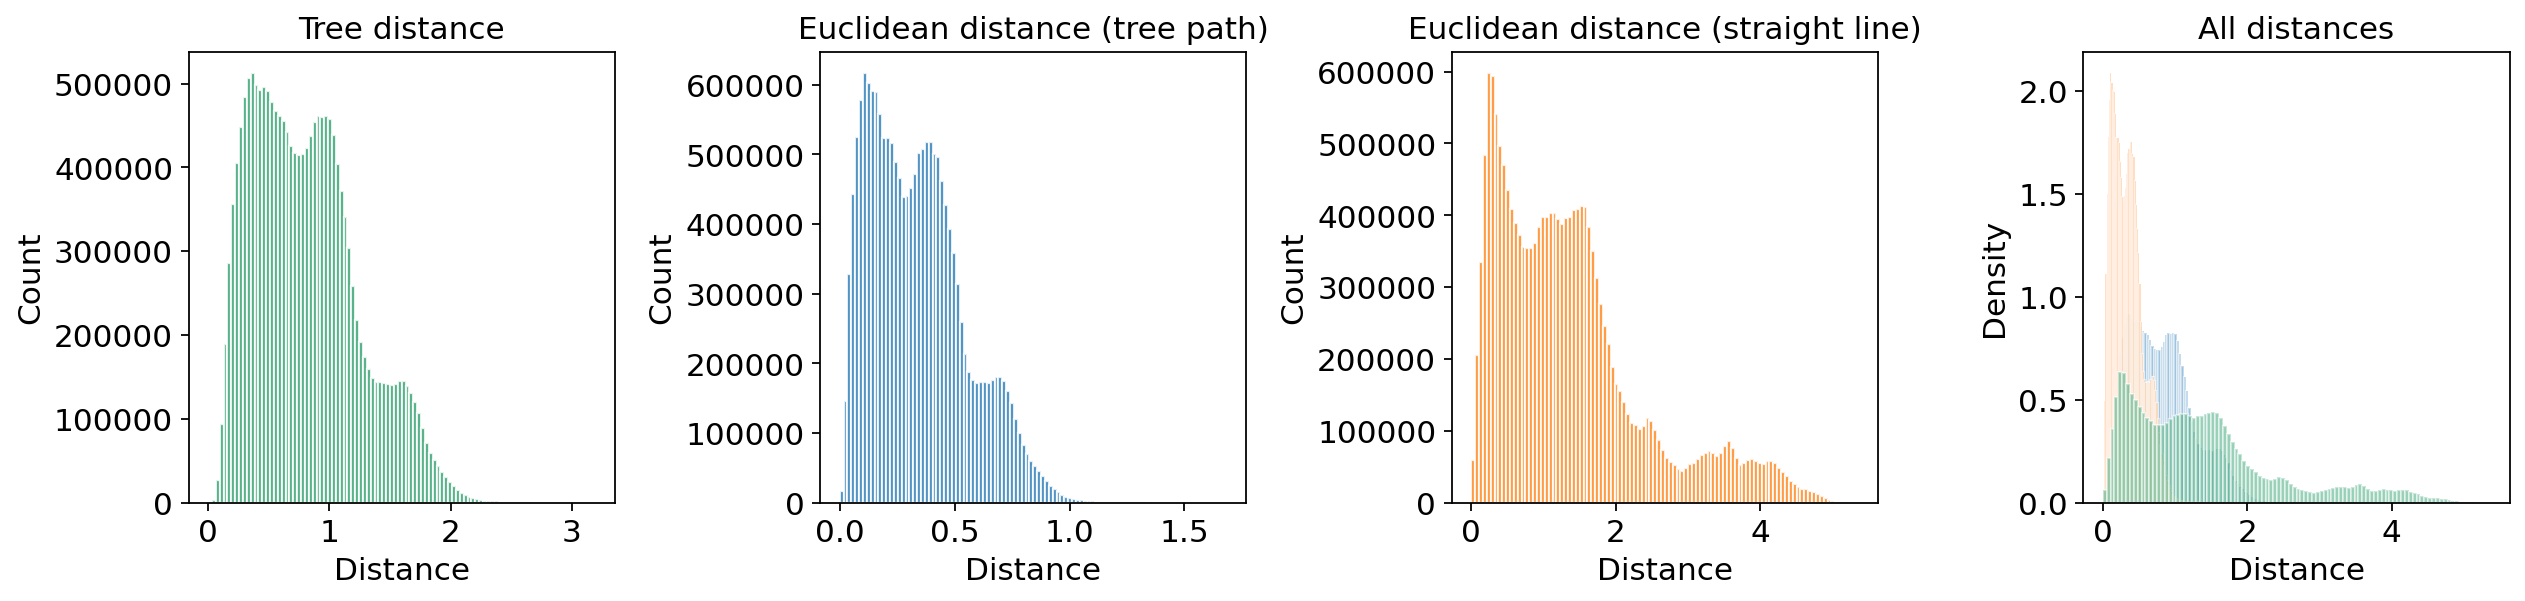

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].hist(
    squareform(tree_distances), bins=100, color="C2", alpha=0.85, edgecolor="white"
)
axes[0].set_title("Tree distance")
axes[0].set_xlabel("Distance")
axes[0].set_ylabel("Count")
axes[0].grid(False)

axes[1].hist(
    squareform(euclidean_distances_tree),
    bins=100,
    color="C0",
    alpha=0.85,
    edgecolor="white",
)
axes[1].set_title("Euclidean distance (tree path)")
axes[1].set_xlabel("Distance")
axes[1].set_ylabel("Count")
axes[1].grid(False)

axes[2].hist(
    squareform(euclidean_distances), bins=100, color="C1", alpha=0.85, edgecolor="white"
)
axes[2].set_title("Euclidean distance (straight line)")
axes[2].set_xlabel("Distance")
axes[2].set_ylabel("Count")
axes[2].grid(False)

axes[3].hist(
    squareform(tree_distances),
    bins=100,
    color="C0",
    alpha=0.5,
    edgecolor="white",
    density=True,
)
axes[3].hist(
    squareform(euclidean_distances_tree),
    bins=100,
    color="C1",
    alpha=0.5,
    edgecolor="white",
    density=True,
)
axes[3].hist(
    squareform(euclidean_distances),
    bins=100,
    color="C2",
    alpha=0.5,
    edgecolor="white",
    density=True,
)
axes[3].set_title("All distances")
axes[3].set_xlabel("Distance")
axes[3].set_ylabel("Density")
axes[3].grid(False)

plt.tight_layout()
plt.show()
plt.close()

In [41]:
# do quantile based matching to tree distance
lo_pct, up_pct = 0.05, 0.95
tree_distances_quantiles = np.quantile(squareform(tree_distances), [lo_pct, up_pct])
euclidean_distances_quantiles = np.quantile(
    squareform(euclidean_distances), [lo_pct, up_pct]
)
euclidean_distances_quantiles_tree = np.quantile(
    squareform(euclidean_distances_tree), [lo_pct, up_pct]
)

# stretch euclidean distances to tree distance range
euclidean_distances_match = squareform(
    np.maximum(
        (squareform(euclidean_distances) - euclidean_distances_quantiles[0])
        / (euclidean_distances_quantiles[1] - euclidean_distances_quantiles[0])
        * (tree_distances_quantiles[1] - tree_distances_quantiles[0])
        + tree_distances_quantiles[0],
        0,
    )
)
euclidean_distances_match_tree = squareform(
    np.maximum(
        (squareform(euclidean_distances_tree) - euclidean_distances_quantiles_tree[0])
        / (
            euclidean_distances_quantiles_tree[1]
            - euclidean_distances_quantiles_tree[0]
        )
        * (tree_distances_quantiles[1] - tree_distances_quantiles[0])
        + tree_distances_quantiles[0],
        0,
    )
)

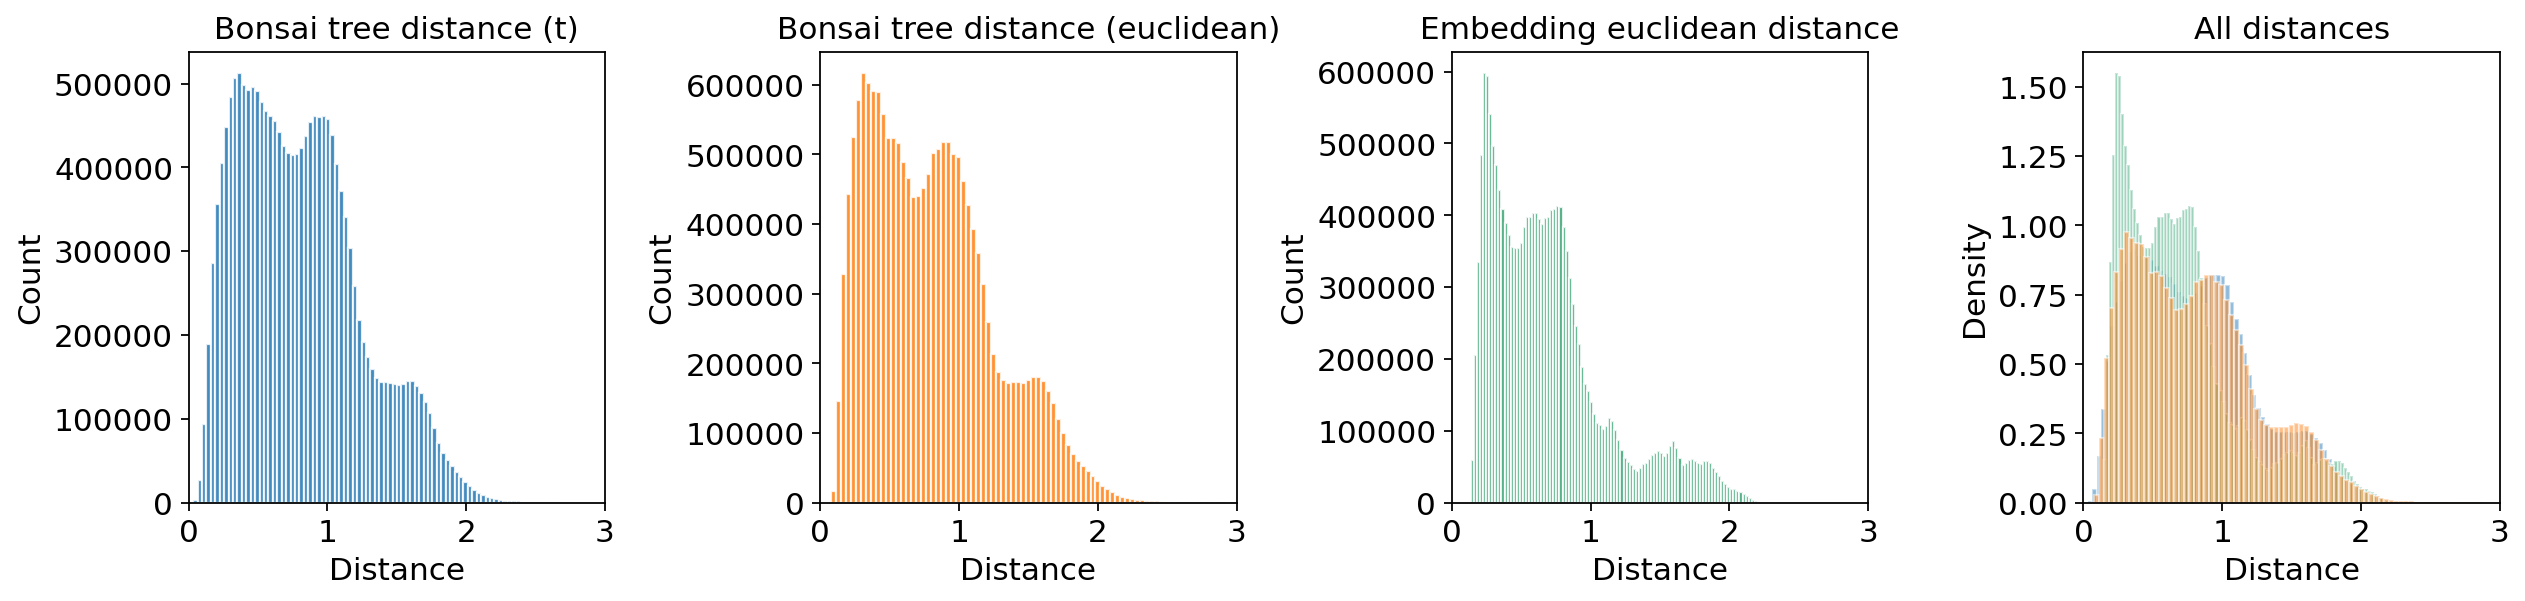

In [85]:
# recheck distributions
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].hist(
    squareform(tree_distances), bins=100, color="C0", alpha=0.85, edgecolor="white"
)
axes[0].set_title("Bonsai tree distance (t)")
axes[0].set_xlabel("Distance")
axes[0].set_ylabel("Count")
axes[0].grid(False)

axes[1].hist(
    squareform(euclidean_distances_match_tree),
    bins=100,
    color="C1",
    alpha=0.85,
    edgecolor="white",
)
axes[1].set_title("Bonsai tree distance (euclidean)")
axes[1].set_xlabel("Distance")
axes[1].set_ylabel("Count")
axes[1].grid(False)

axes[2].hist(
    squareform(euclidean_distances_match),
    bins=100,
    color="C2",
    alpha=0.85,
    edgecolor="white",
)
axes[2].set_title("Embedding euclidean distance")
axes[2].set_xlabel("Distance")
axes[2].set_ylabel("Count")
axes[2].grid(False)

axes[3].hist(
    squareform(tree_distances),
    bins=100,
    color="C0",
    alpha=0.5,
    edgecolor="white",
    density=True,
)
axes[3].hist(
    squareform(euclidean_distances_match),
    bins=100,
    color="C2",
    alpha=0.5,
    edgecolor="white",
    density=True,
)
axes[3].hist(
    squareform(euclidean_distances_match_tree),
    bins=100,
    color="C1",
    alpha=0.5,
    edgecolor="white",
    density=True,
)
axes[3].set_title("All distances")
axes[3].set_xlabel("Distance")
axes[3].set_ylabel("Density")
axes[3].grid(False)

for ax in axes:
    ax.set_xlim([0, 3])

plt.tight_layout()
plt.savefig("bonsai_qc_distances_2.png", dpi=300)
plt.show()
plt.close()

In [48]:
import json
import sys

import h5py
import networkx as nx
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

sys.path.insert(0, "/home/stan/Git/micropattern/Bonsai-data-representation")
from downstream_analyses.get_clusters_max_diameter import (
    get_annotation_based_clustering_from_nwk_str,
    get_cluster_assignments,
)

with h5py.File("./heemskerk_data/Bonsai_48h-1_hvg/bonsai_vis_data.hdf", "r") as f:
    metadata = json.loads(f.attrs["metadata_json"])
cell_ids = metadata["cellIds"]
adata = adata[cell_ids].copy()

annotation_dict = adata.obs["leiden_sub"].to_dict()
with open(bonsai_output_folder / "tree.nwk") as f:
    nwk_str = f.read().strip()
clusters, cut_edges, nmi = get_annotation_based_clustering_from_nwk_str(
    tree_nwk_str=nwk_str, annotation_dict=annotation_dict, cutting_tol=0.005
)
cluster_dict = get_cluster_assignments({"annot": clusters})
adata.obs["bonsai_cluster"] = (
    cluster_dict["annot"].reindex(adata.obs.index).fillna("-1")
)
adata.obs["bonsai_cluster"] = adata.obs["bonsai_cluster"].astype(str).astype("category")

node_id_to_vert_ind = {}
with open(bonsai_output_folder / "vertInfo.txt") as f:
    next(f)
    for line in f:
        parts = line.strip().split("\t")
        node_id_to_vert_ind[parts[2]] = int(parts[0])

G = nx.Graph()
with open(bonsai_output_folder / "edgeInfo.txt") as f:
    for line in f:
        v1, v2, d = line.strip().split("\t")
        G.add_edge(int(v1), int(v2), weight=np.sqrt(float(d)))

order_row = True
order_by_cell_t = True
order_by_cluster_t = True
white_list_cell_types = []

cell_ids = adata.obs.index.to_list()
cell_vert_inds = [node_id_to_vert_ind[cid] for cid in cell_ids]
cell_type_vec = adata.obs.loc[cell_ids, "leiden_sub"].copy()
cluster_vec = adata.obs.loc[cell_ids, "bonsai_cluster"].copy()
clusters = cluster_vec.cat.categories

for c in white_list_cell_types:
    ct_distrib = cluster_vec[cell_type_vec == c].value_counts()
    most_occur_branch = ct_distrib.idxmax()
    cluster_vec[
        np.logical_and(cell_type_vec == c, cluster_vec != most_occur_branch)
    ] = most_occur_branch

root_id = "internal_906"
_tree_t = nx.shortest_path_length(
    G, source=node_id_to_vert_ind[root_id], weight="weight"
)
dists_to_root = np.array([_tree_t[cvid] for cvid in cell_vert_inds])
dists_to_root_by_cluster = np.zeros(len(cell_ids))
if order_by_cluster_t:
    for c in clusters:
        dists_to_root_by_cluster[cluster_vec == c] = np.mean(
            dists_to_root[cluster_vec == c]
        )

reorder_ind = np.arange(len(cell_ids))
if order_by_cell_t and order_by_cluster_t:
    reorder_ind = np.lexsort((dists_to_root, dists_to_root_by_cluster))
elif order_by_cell_t:
    reorder_ind = np.argsort(dists_to_root)
elif order_by_cluster_t:
    reorder_ind = np.argsort(dists_to_root_by_cluster)

dist_matrix_tree_t_ordered = tree_distances[:, reorder_ind]
dist_matrix_tree_e_ordered = euclidean_distances_match_tree[:, reorder_ind]
dist_matrix_straight_ordered = euclidean_distances_match[:, reorder_ind]
if order_row:
    dist_matrix_tree_t_ordered = dist_matrix_tree_t_ordered[reorder_ind, :]
    dist_matrix_tree_e_ordered = dist_matrix_tree_e_ordered[reorder_ind, :]
    dist_matrix_straight_ordered = dist_matrix_straight_ordered[reorder_ind, :]

window_size = 30
cell_types = pd.Categorical(adata.obs["leiden_sub"]).categories
colors = adata.uns["leiden_sub_colors"]
cell_composition_matrix = np.zeros((len(cell_types) + 1, len(cell_ids)))
for i, cell_type in enumerate(cell_types):
    res = np.convolve(
        adata.obs.loc[cell_ids, "leiden_sub"][reorder_ind] == cell_type,
        np.ones(window_size),
        mode="valid",
    )
    margin = int(np.ceil((cell_composition_matrix.shape[1] - res.shape[0]) / 2))
    res = np.pad(res, (margin, margin), mode="constant")
    cell_composition_matrix[i, :] = res[: cell_composition_matrix.shape[1]]
cell_composition_matrix[-1, :] = 1
cell_composition_matrix = cell_composition_matrix / np.sum(
    cell_composition_matrix, axis=0
)

04-07 03:05:02 mp_print INFO Annotation-based clustering has done 2 moves, currently 3 clusters, and Normalized Mutual Information of 0.5515271657209468.
04-07 03:05:02 mp_print INFO Annotation-based clustering has done 4 moves, currently 5 clusters, and Normalized Mutual Information of 0.628842271477425.
04-07 03:05:02 mp_print INFO 
After making 7 clusters, norm. mutual information doesn't significantly increase. Stopping here.
04-07 03:05:02 mp_print INFO Final annotation-based clustering did 7 moves, created 7 clusters, with a Normalized Mutual Information of 0.6508135327758374.
04-07 03:05:02 mp_print INFO Clustering done
/tmp/ipykernel_643070/1883823387.py:98: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adata.obs.loc[cell_ids, "leiden_sub"][reorder_ind] == cell_type,
/tmp/ipykernel_643070/1883

In [52]:
class SigmoidNorm(Normalize):
    def __init__(self, vmin=None, vmax=None, scale=1, clip=False):
        self.scale = scale
        super().__init__(vmin, vmax, clip)

    def _sigmoid(self, x):
        center = (self.vmax + self.vmin) / 2
        return 1 / (1 + np.exp(-self.scale * (x - center)))

    def __call__(self, value, clip=None):
        s = self._sigmoid(np.asarray(value, dtype=float))
        s_min = self._sigmoid(self.vmin)
        s_max = self._sigmoid(self.vmax)
        result = (s - s_min) / (s_max - s_min)
        return np.ma.masked_array(result)

    def inverse(self, value):
        s_min = self._sigmoid(self.vmin)
        s_max = self._sigmoid(self.vmax)
        s = np.asarray(value) * (s_max - s_min) + s_min
        s = np.clip(s, 1e-12, 1 - 1e-12)
        center = (self.vmax + self.vmin) / 2
        return center + np.log(s / (1 - s)) / self.scale

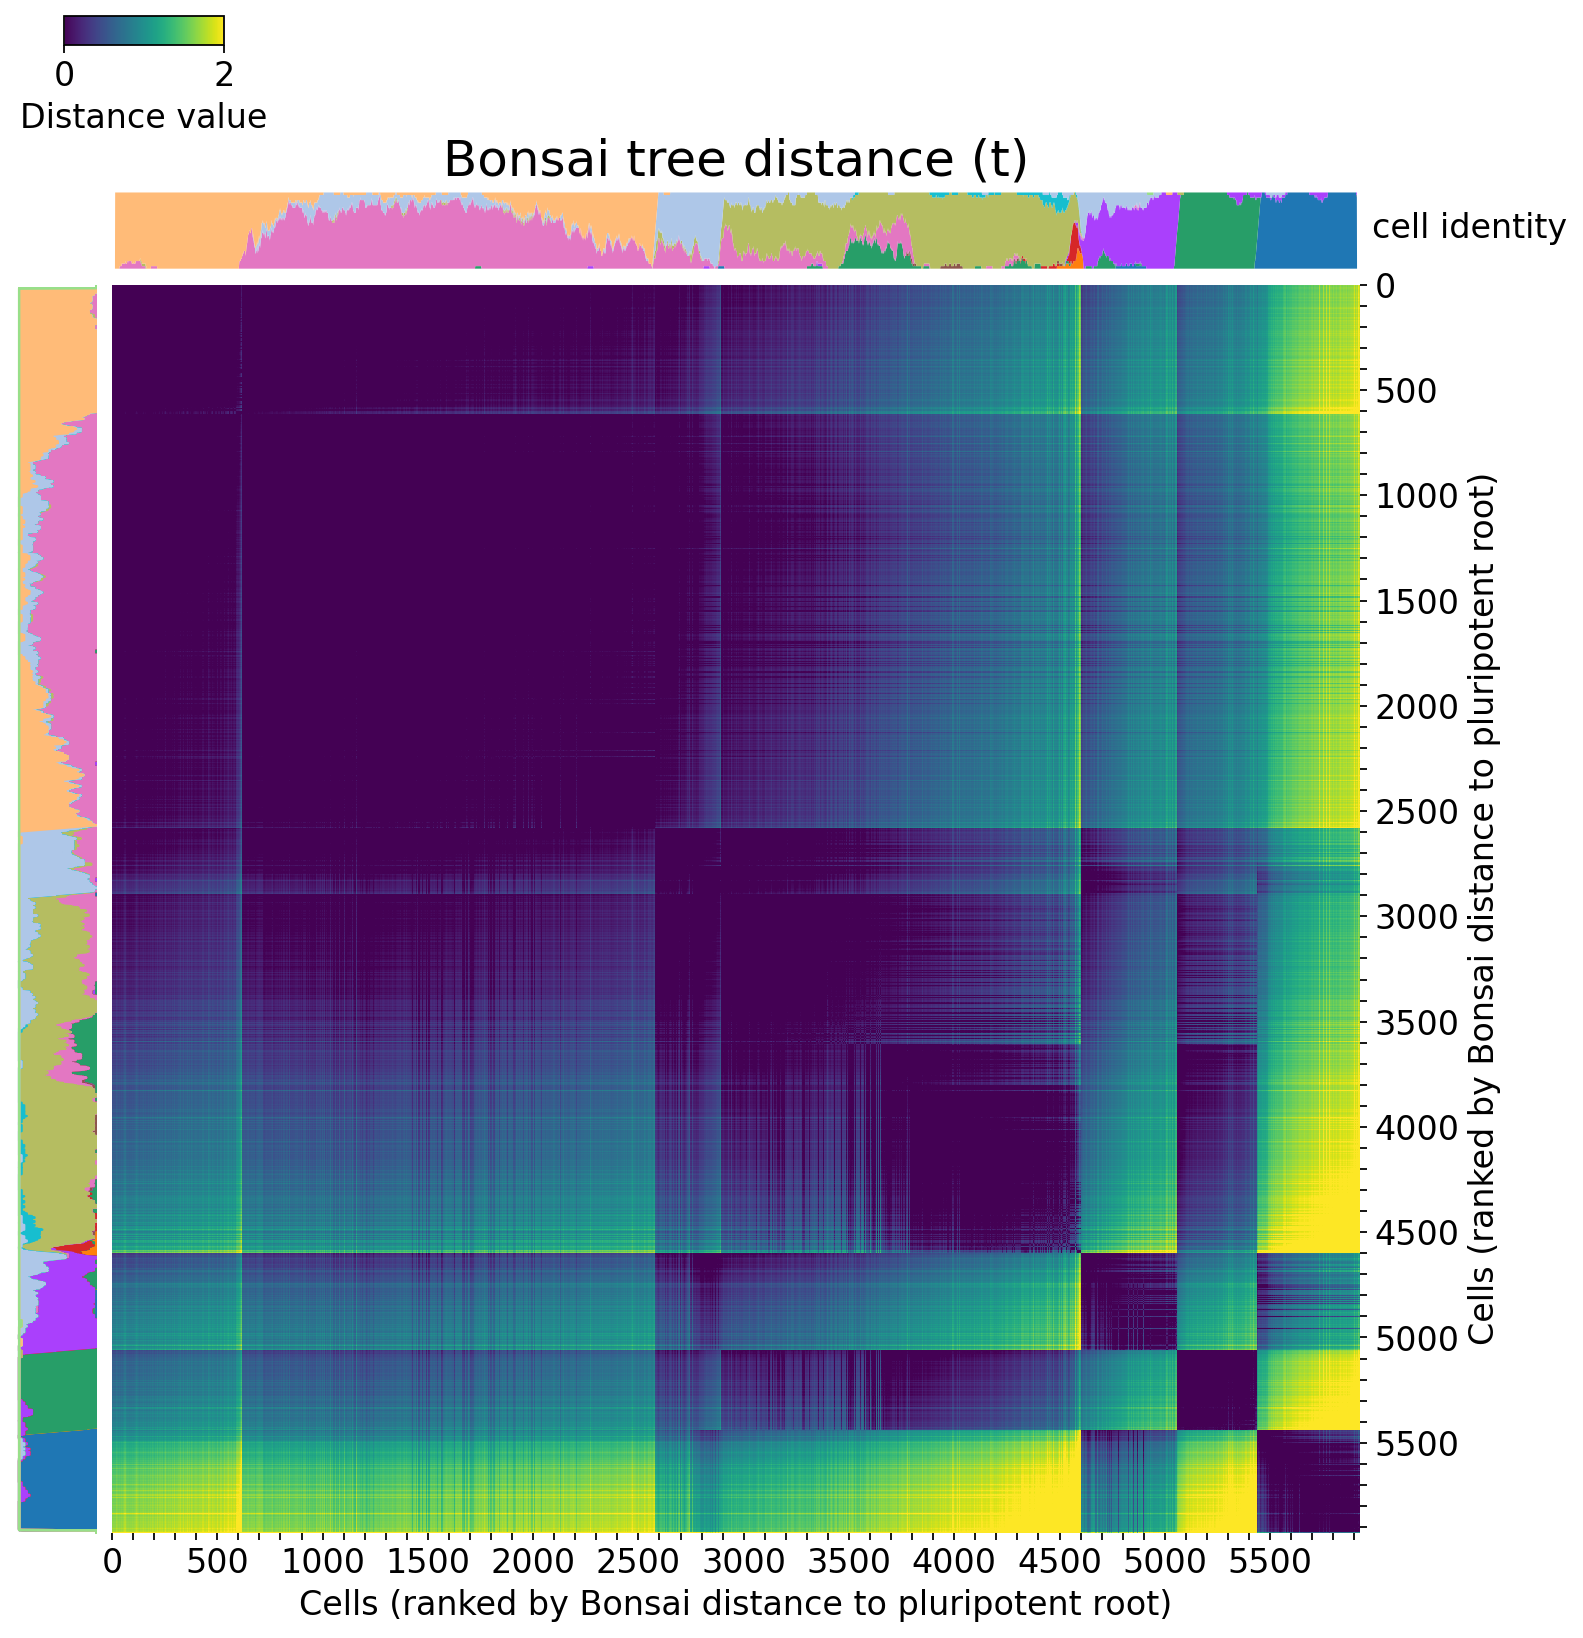

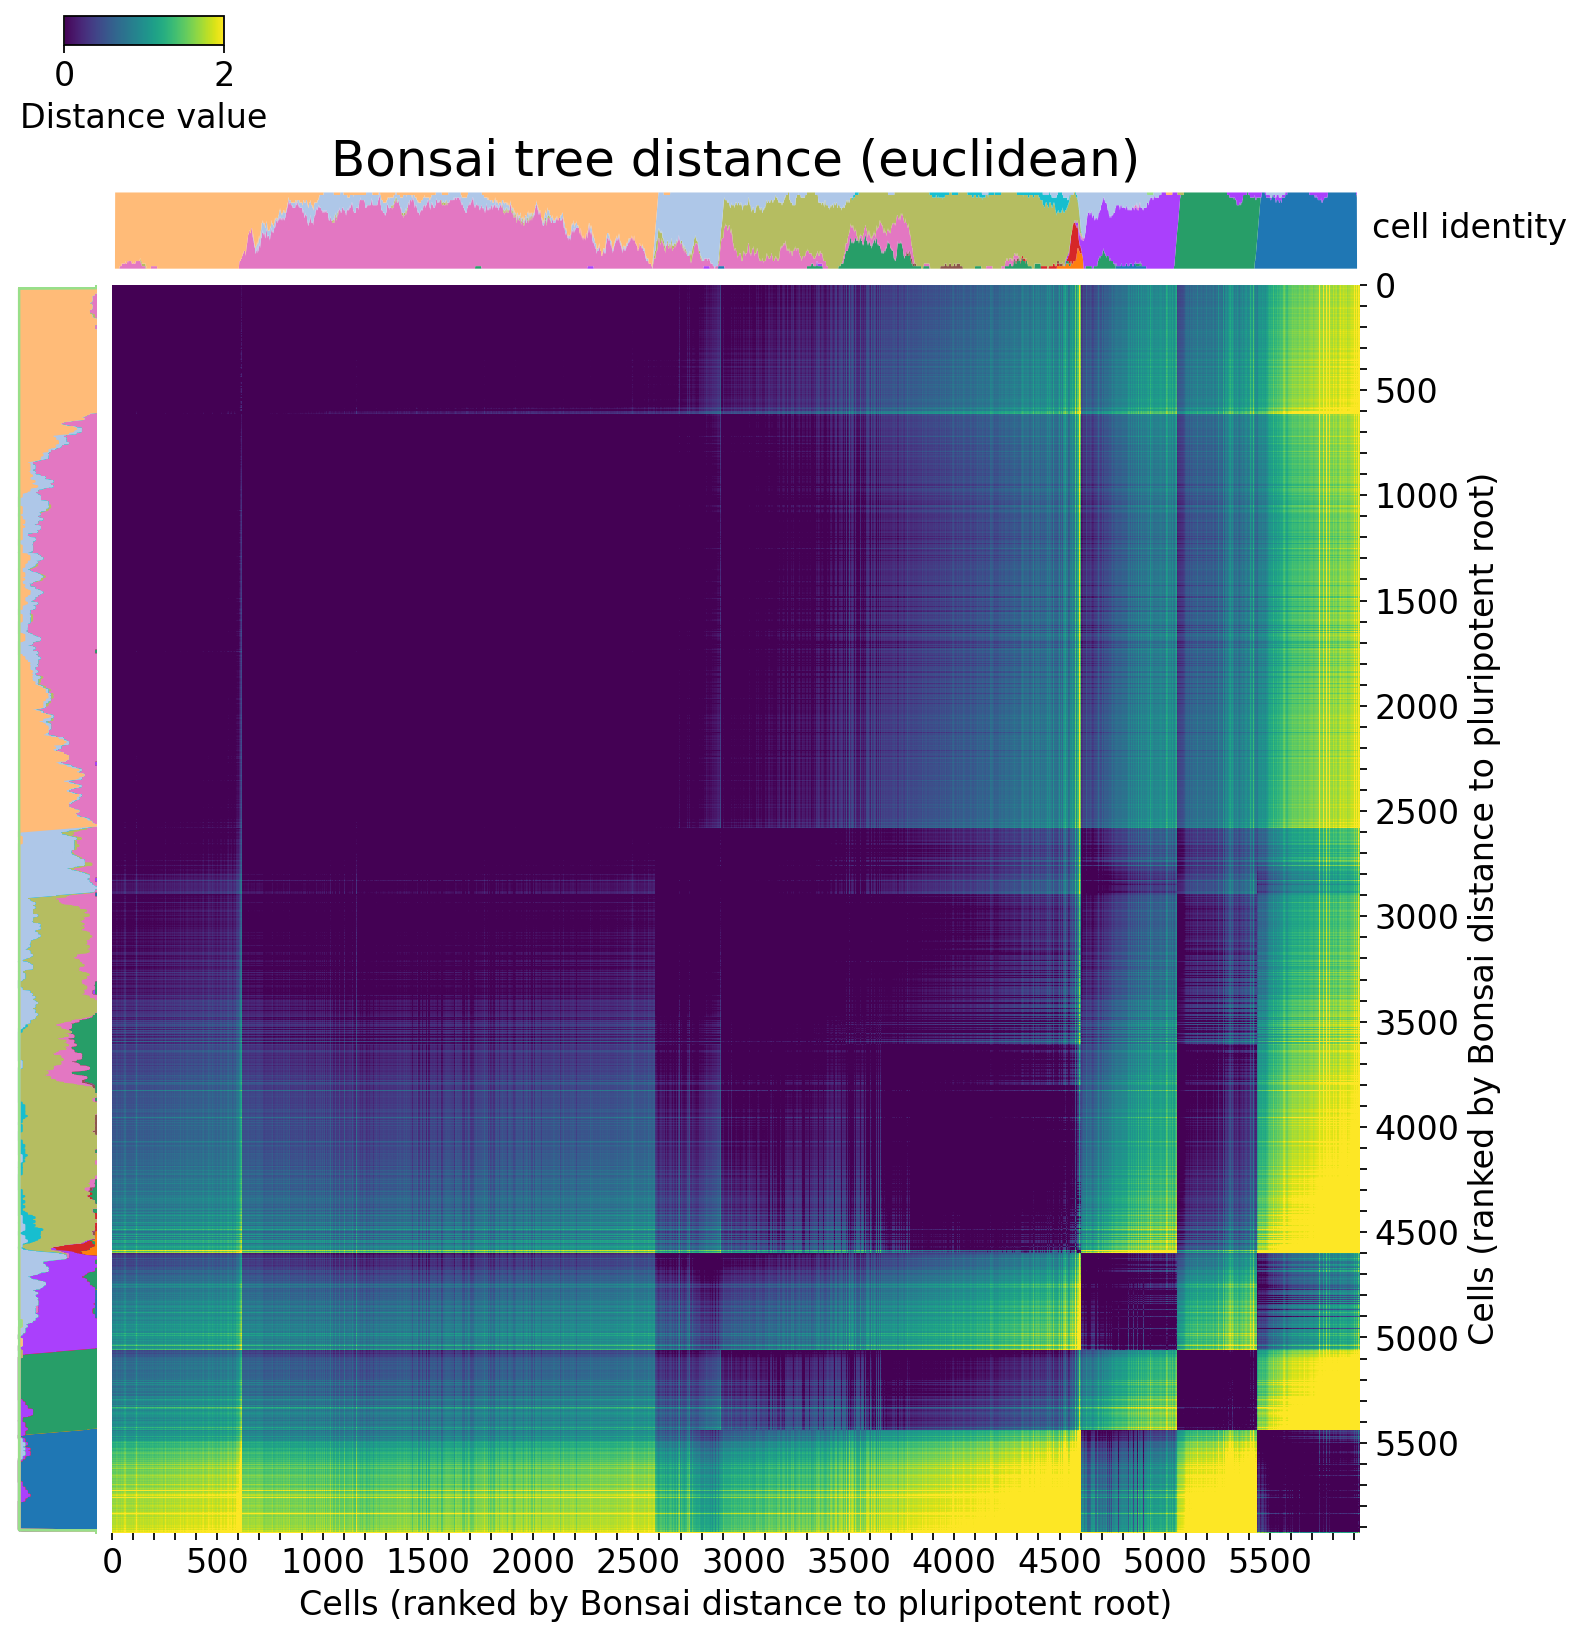

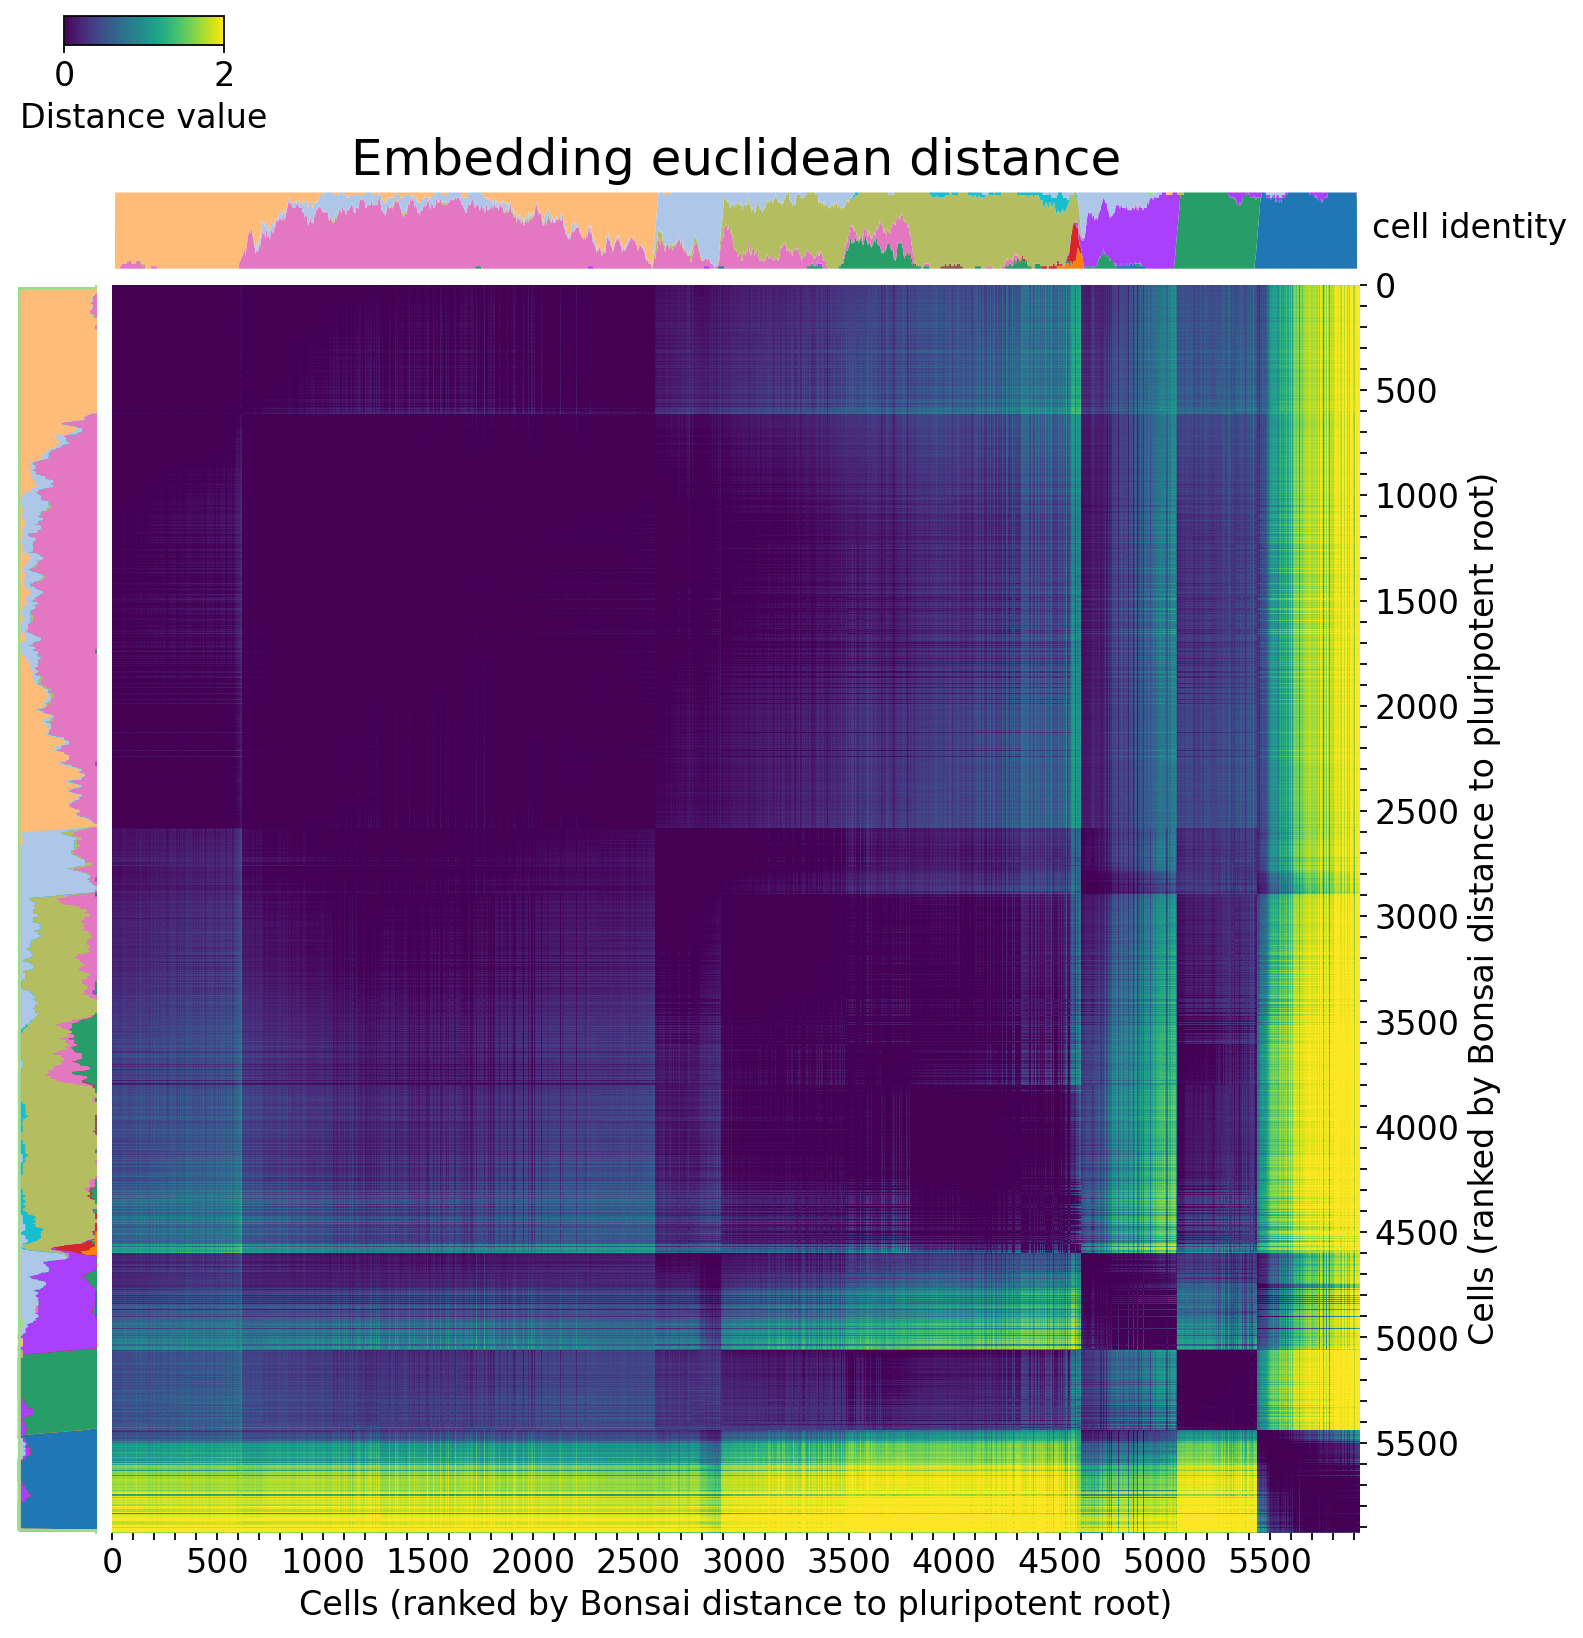

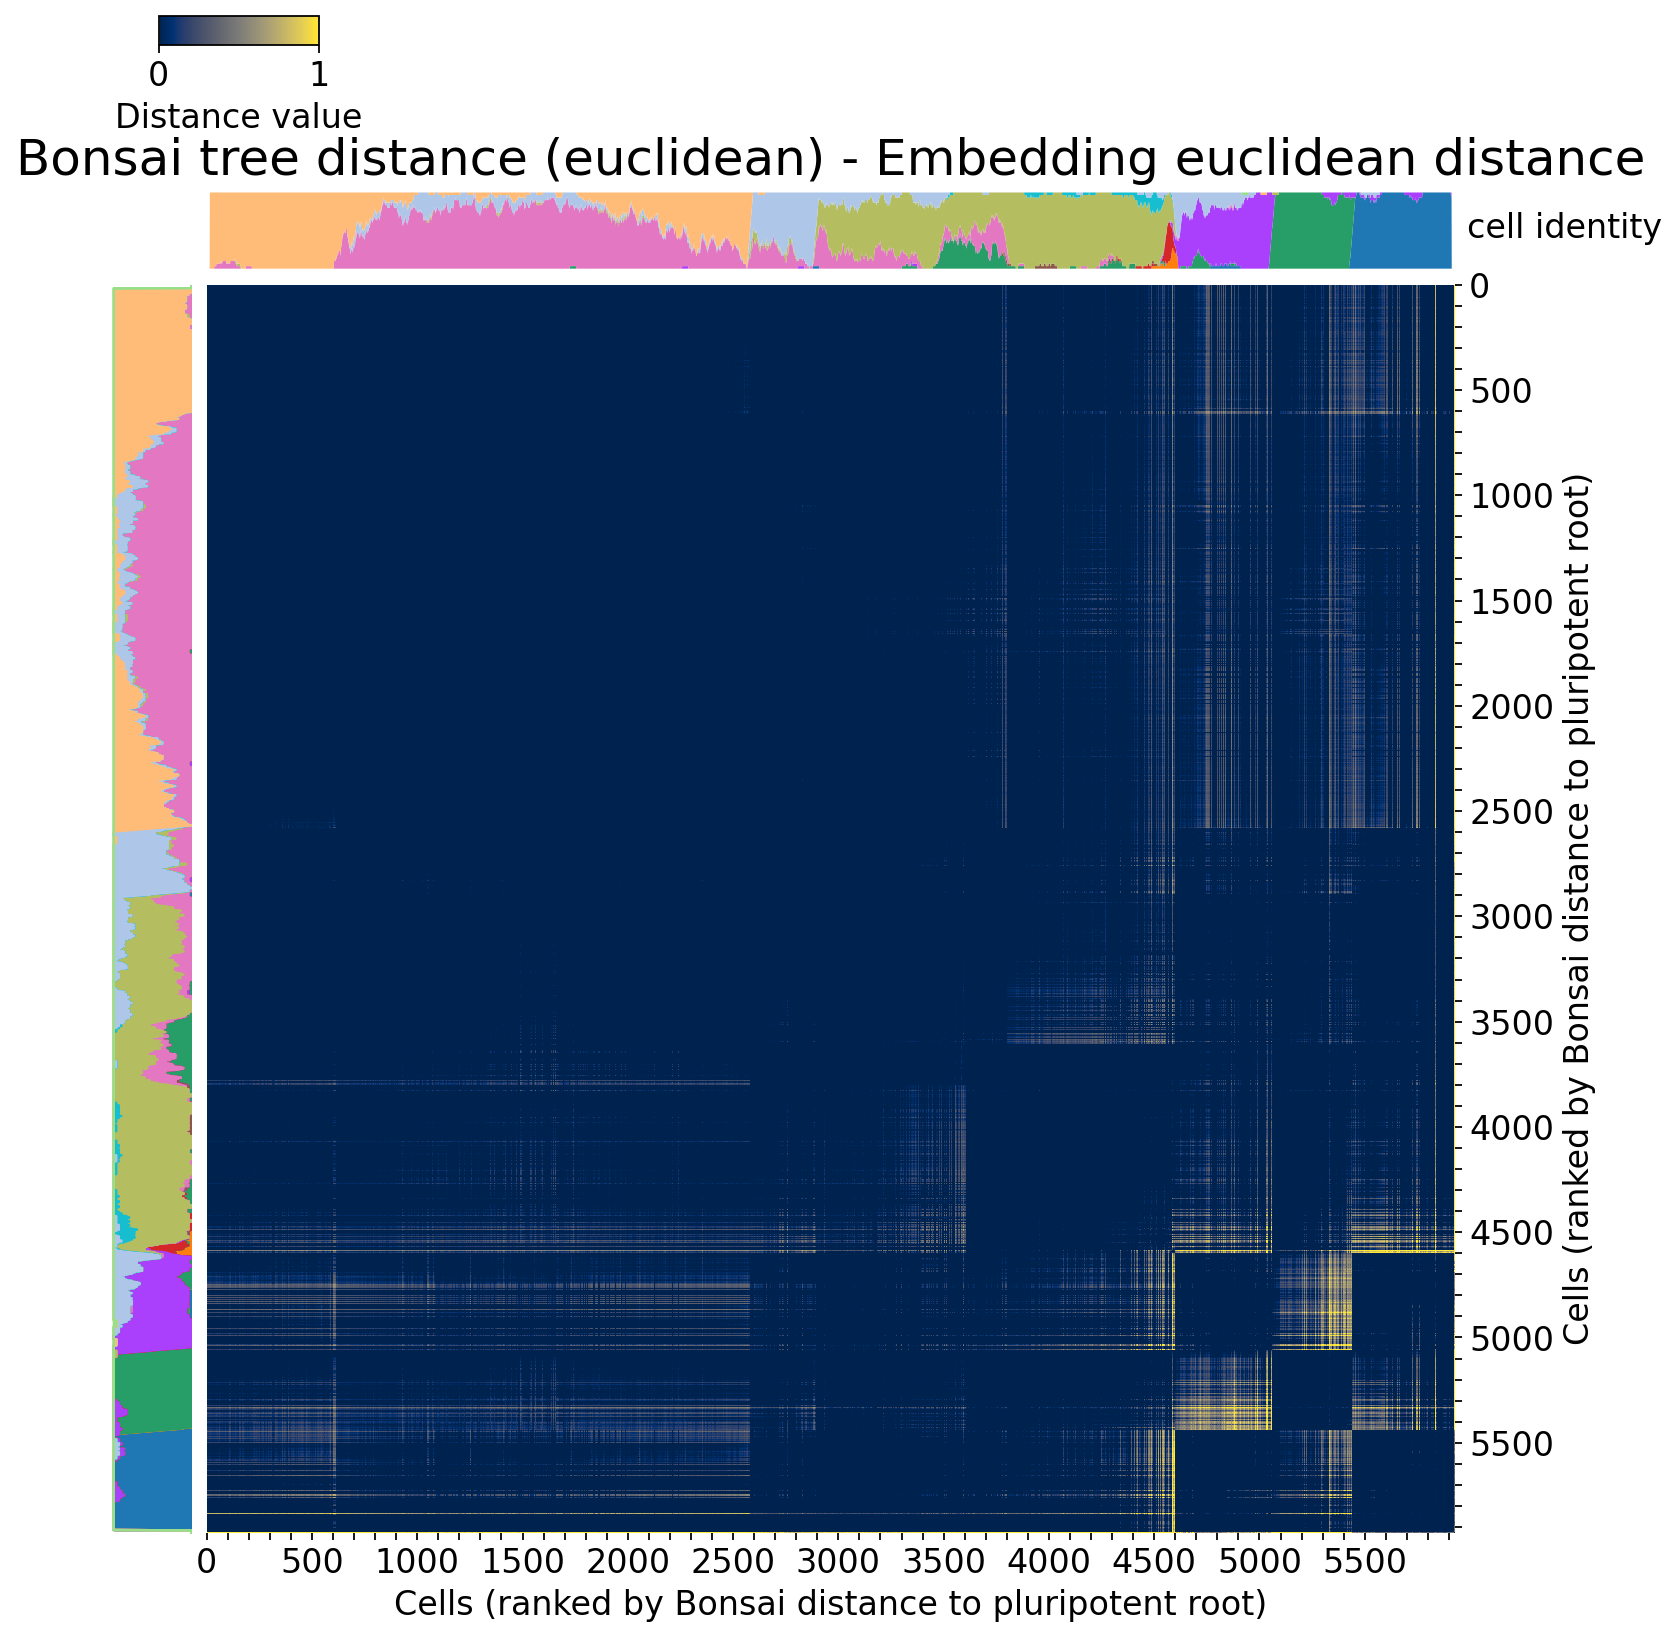

In [86]:
from matplotlib.colors import PowerNorm

FONTSIZE = 15
heatmaps = [
    {
        "mat": dist_matrix_tree_t_ordered,
        "title": "Bonsai tree distance (t)",
        "filename": "bonsai_distance_heatmap_tree_t.png",
        "normalize": True,
        "cmap": "viridis",
        "norm_type": "power",
        "power_gamma": 1.0,
        "sigmoid_scale": 8,
        "vmin": 0.15,
        "vmax": 0.6,
        "cbar_low_label": 0,
        "cbar_high_label": 2,
    },
    {
        "mat": dist_matrix_tree_e_ordered,
        "title": "Bonsai tree distance (euclidean)",
        "filename": "bonsai_distance_heatmap_euclidean_tree_matched.png",
        "normalize": True,
        "cmap": "viridis",
        "norm_type": "power",
        "power_gamma": 1.0,
        "sigmoid_scale": 8,
        "vmin": 0.15,
        "vmax": 0.5,
        "cbar_low_label": 0,
        "cbar_high_label": 2,
    },
    {
        "mat": dist_matrix_straight_ordered,
        "title": "Embedding euclidean distance",
        "filename": "bonsai_distance_heatmap_euclidean_straight_matched.png",
        "normalize": True,
        "cmap": "viridis",
        "norm_type": "sigmoid",
        "power_gamma": 1.0,
        "sigmoid_scale": 8,
        "vmin": 0.15,
        "vmax": 0.8,
        "cbar_low_label": 0,
        "cbar_high_label": 2,
    },
    {
        "mat": dist_matrix_tree_e_ordered - dist_matrix_straight_ordered,
        "title": "Bonsai tree distance (euclidean) - Embedding euclidean distance",
        "filename": "bonsai_distance_heatmap_euclidean_difference.png",
        "normalize": "sigmoid",
        "cmap": "cividis",
        "norm_type": None,
        "power_gamma": 1.0,
        "sigmoid_scale": 12,
        "vmin": 0.12,
        "vmax": 0.4,
        "cbar_low_label": 0,
        "cbar_high_label": 1,
    },
]

for heatmap in heatmaps:
    plot_mat = (heatmap["mat"] + heatmap["mat"].T) / 2
    if heatmap["normalize"]:
        maxval = np.max(plot_mat)
        if maxval == 0:
            maxval = 1
        plot_mat = plot_mat / maxval

    vmin = heatmap["vmin"]
    vmax = heatmap["vmax"]
    if vmin is None:
        vmin = float(np.min(plot_mat))
    if vmax is None:
        vmax = float(np.max(plot_mat))
    if vmin == vmax:
        vmax = vmin + 1

    if heatmap["norm_type"] == "power":
        norm = PowerNorm(gamma=heatmap["power_gamma"], vmin=vmin, vmax=vmax)
    elif heatmap["norm_type"] == "sigmoid":
        norm = SigmoidNorm(vmin=vmin, vmax=vmax, scale=heatmap["sigmoid_scale"])
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)

    low_label = heatmap["cbar_low_label"]
    high_label = heatmap["cbar_high_label"]
    if low_label is None:
        low_label = f"{vmin:.2f}"
    if high_label is None:
        high_label = f"{vmax:.2f}"

    if vmin < 0 < vmax:
        cbar_ticks = [vmin, 0.0, vmax]
        cbar_ticklabels = [low_label, "0", high_label]
    else:
        cbar_ticks = [vmin, vmax]
        cbar_ticklabels = [low_label, high_label]
    cbar_label = "Distance value" if heatmap["normalize"] else "Difference value"

    g = sns.clustermap(
        plot_mat,
        cmap=heatmap["cmap"],
        cbar=True,
        square=False,
        xticklabels=False,
        yticklabels=False,
        row_cluster=False,
        col_cluster=False,
        figsize=(10, 10),
        rasterized=True,
        norm=norm,
    )
    ax_hm = g.ax_heatmap
    ax_hm.set_aspect("equal")
    g.ax_row_dendrogram.set_visible(False)
    g.ax_col_dendrogram.set_visible(False)
    g.cax.set_visible(False)

    ax_hm.set_position([0.1, 0.08, 0.78, 0.78])
    pos = ax_hm.get_position()

    n = plot_mat.shape[1]
    n_rows = plot_mat.shape[0]
    x = np.arange(n)
    y = np.arange(n_rows)

    tick_x = np.arange(0, n, 100)
    tick_x_labels = [str(int(t)) if t % 500 == 0 else "" for t in tick_x]
    ax_hm.set_xticks(tick_x)
    ax_hm.set_xticklabels(tick_x_labels, fontsize=FONTSIZE)
    ax_hm.tick_params(axis="x", which="major", length=3, direction="out")
    ax_hm.grid(False)

    tick_y = np.arange(0, n_rows, 100)
    tick_y_labels = [str(int(t)) if t % 500 == 0 else "" for t in tick_y]
    ax_hm.set_yticks(tick_y)
    ax_hm.set_yticklabels(tick_y_labels, fontsize=FONTSIZE)
    ax_hm.tick_params(axis="y", which="major", length=3, direction="out")
    ax_hm.set_xlabel(
        "Cells (ranked by Bonsai distance to pluripotent root)", fontsize=FONTSIZE
    )
    ax_hm.set_ylabel(
        "Cells (ranked by Bonsai distance to pluripotent root)", fontsize=FONTSIZE
    )

    ax_top = g.fig.add_axes([pos.x0, pos.y1 + 0.01, pos.width, 0.05])
    ax_top.stackplot(
        x, cell_composition_matrix[:-1, :], labels=cell_types, colors=colors
    )
    ax_top.set_xlim(ax_hm.get_xlim())
    ax_top.axis("off")
    ax_top.text(
        1.01,
        0.5,
        "cell identity",
        transform=ax_top.transAxes,
        ha="left",
        va="center",
        rotation=0,
        fontsize=FONTSIZE,
        clip_on=False,
    )

    ax_left = g.fig.add_axes([pos.x0 - 0.06, pos.y0, 0.05, pos.height])
    cumulative = np.cumsum(cell_composition_matrix[:-1, :], axis=0)
    prev = np.zeros(n_rows)
    for i in range(cumulative.shape[0]):
        ax_left.fill_betweenx(y, prev, cumulative[i], color=colors[i])
        prev = cumulative[i]
    ax_left.set_xlim(1, 0)
    ax_left.set_ylim(ax_hm.get_ylim())
    ax_left.axis("off")

    ax_top.set_title(heatmap["title"], fontsize=FONTSIZE * 1.5)

    mappable = ScalarMappable(norm=norm, cmap=heatmap["cmap"])
    mappable.set_array([])
    cax = g.fig.add_axes([pos.x0 - 0.03, 1.01, 0.1, 0.018])
    cb = g.fig.colorbar(mappable, cax=cax, orientation="horizontal")
    cb.set_ticks(cbar_ticks)
    cb.set_ticklabels(cbar_ticklabels)
    cb.set_label(cbar_label, fontsize=FONTSIZE, labelpad=4)
    cb.ax.tick_params(labelsize=FONTSIZE)

    plt.savefig(heatmap["filename"], dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

# Toy dataset

In [90]:
# import some classes and functions
import pathlib

bonsai_output_folder = pathlib.Path(
    "/home/stan/Git/micropattern/notebooks/heemskerk_data/Bonsai_toy/bonsai/final_bonsai_zscore1.0_tmpStartpremerged_cs_tree/"
)

# get cell ids
tree = Layout_Tree()
with open(bonsai_output_folder / "tree.nwk", "r") as f:
    nwk_str = f.readline()
tree.from_newick(nwk_str=nwk_str)
vertIndToNode, tree.nNodes = tree.root.renumber_verts(vertIndToNode={}, vert_count=0)
tree.vert_ind_to_node = vertIndToNode
tree.root.storeParent()
cell_ids = [node.nodeId for node in tree.vert_ind_to_node.values()]

# straight-line squared euclidean distances
euclidean_distances = squareform(
    get_bonsai_euclidean_distances(
        final_bonsai_folder=bonsai_output_folder,
        cell_ids=cell_ids,
    )
)
# tree distance
tree_distances = squareform(
    get_pdists_on_tree(
        nwk_file=bonsai_output_folder / "tree.nwk",
        cell_ids=cell_ids,
    )
)


# euclidean distances based on tree path
def get_pdists_on_tree_modified(nwk_file, cell_ids):
    # Read in newick file
    tree = Layout_Tree()

    with open(nwk_file, "r") as f:
        nwk_str = f.readline()

    tree.from_newick(nwk_str=nwk_str)

    # Renumber vert_inds on tree such that they are in line with a depth-first search
    vertIndToNode, tree.nNodes = tree.root.renumber_verts(
        vertIndToNode={}, vert_count=0
    )
    tree.vert_ind_to_node = vertIndToNode
    tree.root.storeParent()
    # replace tree distance with euclidean distance
    # same as get_pairwise_dist_on_tree with only weights replaced by squared euclidean distances
    node_id_to_vert_ind = {
        node.nodeId: vert_ind for vert_ind, node in tree.vert_ind_to_node.items()
    }
    indices = [node_id_to_vert_ind[node_id] for node_id in cell_ids]
    edge_dict = tree.get_edge_dict(nodeIdToVertInd=node_id_to_vert_ind)
    cols = edge_dict["source"]
    rows = edge_dict["target"]
    dist_mat = squareform(
        get_bonsai_euclidean_distances(
            bonsai_output_folder, list(node_id_to_vert_ind.keys())
        )
    )
    idx_lookup = {k: i for i, k in enumerate(node_id_to_vert_ind.keys())}
    weights = [dist_mat[idx_lookup[s], idx_lookup[t]] for s, t in zip(cols, rows)]
    cols = edge_dict["source_ind"]
    rows = edge_dict["target_ind"]

    colsComplete = np.concatenate((cols, rows))
    rowsComplete = np.concatenate((rows, cols))
    weightsComplete = np.concatenate((weights, weights))
    nVerts = np.max(colsComplete) + 1
    distance_csr = csr_matrix(
        (weightsComplete, (rowsComplete, colsComplete)), shape=(nVerts, nVerts)
    )

    print("Done preparing inputs. Starting shortest-path algorithm from Scipy.")
    distances = squareform(
        shortest_path(
            distance_csr,
            method="auto",
            directed=False,
            return_predecessors=False,
            unweighted=False,
            overwrite=False,
            indices=indices,
        )[:, indices],
        checks=False,
    )
    return distances


# squared euclidean distances based on tree path
euclidean_distances_tree = squareform(
    get_pdists_on_tree_modified(
        nwk_file=bonsai_output_folder / "tree.nwk", cell_ids=cell_ids
    )
)

Done preparing inputs. Starting shortest-path algorithm from Scipy.
Done preparing inputs. Starting shortest-path algorithm from Scipy.


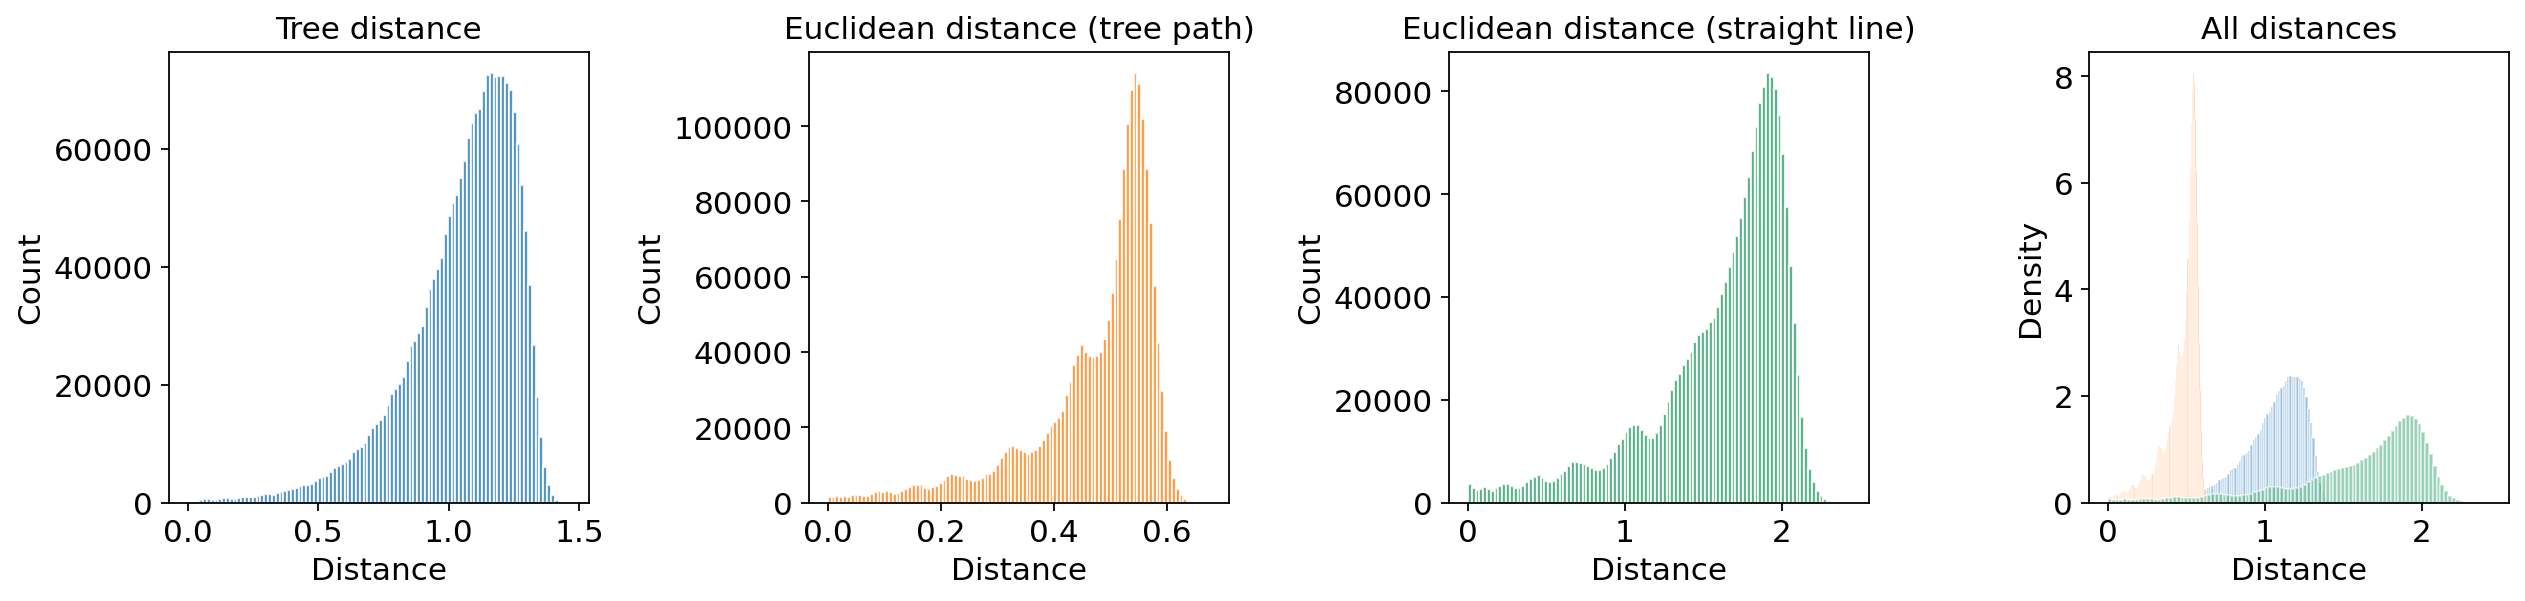

In [91]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].hist(
    squareform(tree_distances), bins=100, color="C0", alpha=0.85, edgecolor="white"
)
axes[0].set_title("Tree distance")
axes[0].set_xlabel("Distance")
axes[0].set_ylabel("Count")
axes[0].grid(False)

axes[1].hist(
    squareform(euclidean_distances_tree),
    bins=100,
    color="C1",
    alpha=0.85,
    edgecolor="white",
)
axes[1].set_title("Euclidean distance (tree path)")
axes[1].set_xlabel("Distance")
axes[1].set_ylabel("Count")
axes[1].grid(False)

axes[2].hist(
    squareform(euclidean_distances), bins=100, color="C2", alpha=0.85, edgecolor="white"
)
axes[2].set_title("Euclidean distance (straight line)")
axes[2].set_xlabel("Distance")
axes[2].set_ylabel("Count")
axes[2].grid(False)

axes[3].hist(
    squareform(tree_distances),
    bins=100,
    color="C0",
    alpha=0.5,
    edgecolor="white",
    density=True,
)
axes[3].hist(
    squareform(euclidean_distances_tree),
    bins=100,
    color="C1",
    alpha=0.5,
    edgecolor="white",
    density=True,
)
axes[3].hist(
    squareform(euclidean_distances),
    bins=100,
    color="C2",
    alpha=0.5,
    edgecolor="white",
    density=True,
)
axes[3].set_title("All distances")
axes[3].set_xlabel("Distance")
axes[3].set_ylabel("Density")
axes[3].grid(False)

plt.tight_layout()
plt.show()
plt.close()

In [92]:
# similarly, do quantile based matching to tree distance
lo_pct, up_pct = 0.05, 0.95
tree_distances_quantiles = np.quantile(squareform(tree_distances), [lo_pct, up_pct])
euclidean_distances_quantiles = np.quantile(
    squareform(euclidean_distances), [lo_pct, up_pct]
)
euclidean_distances_quantiles_tree = np.quantile(
    squareform(euclidean_distances_tree), [lo_pct, up_pct]
)
# stretch euclidean distances to tree distance range
euclidean_distances_match = squareform(
    np.maximum(
        (squareform(euclidean_distances) - euclidean_distances_quantiles[0])
        / (euclidean_distances_quantiles[1] - euclidean_distances_quantiles[0])
        * (tree_distances_quantiles[1] - tree_distances_quantiles[0])
        + tree_distances_quantiles[0],
        0,
    )
)
euclidean_distances_match_tree = squareform(
    np.maximum(
        (squareform(euclidean_distances_tree) - euclidean_distances_quantiles_tree[0])
        / (
            euclidean_distances_quantiles_tree[1]
            - euclidean_distances_quantiles_tree[0]
        )
        * (tree_distances_quantiles[1] - tree_distances_quantiles[0])
        + tree_distances_quantiles[0],
        0,
    )
)

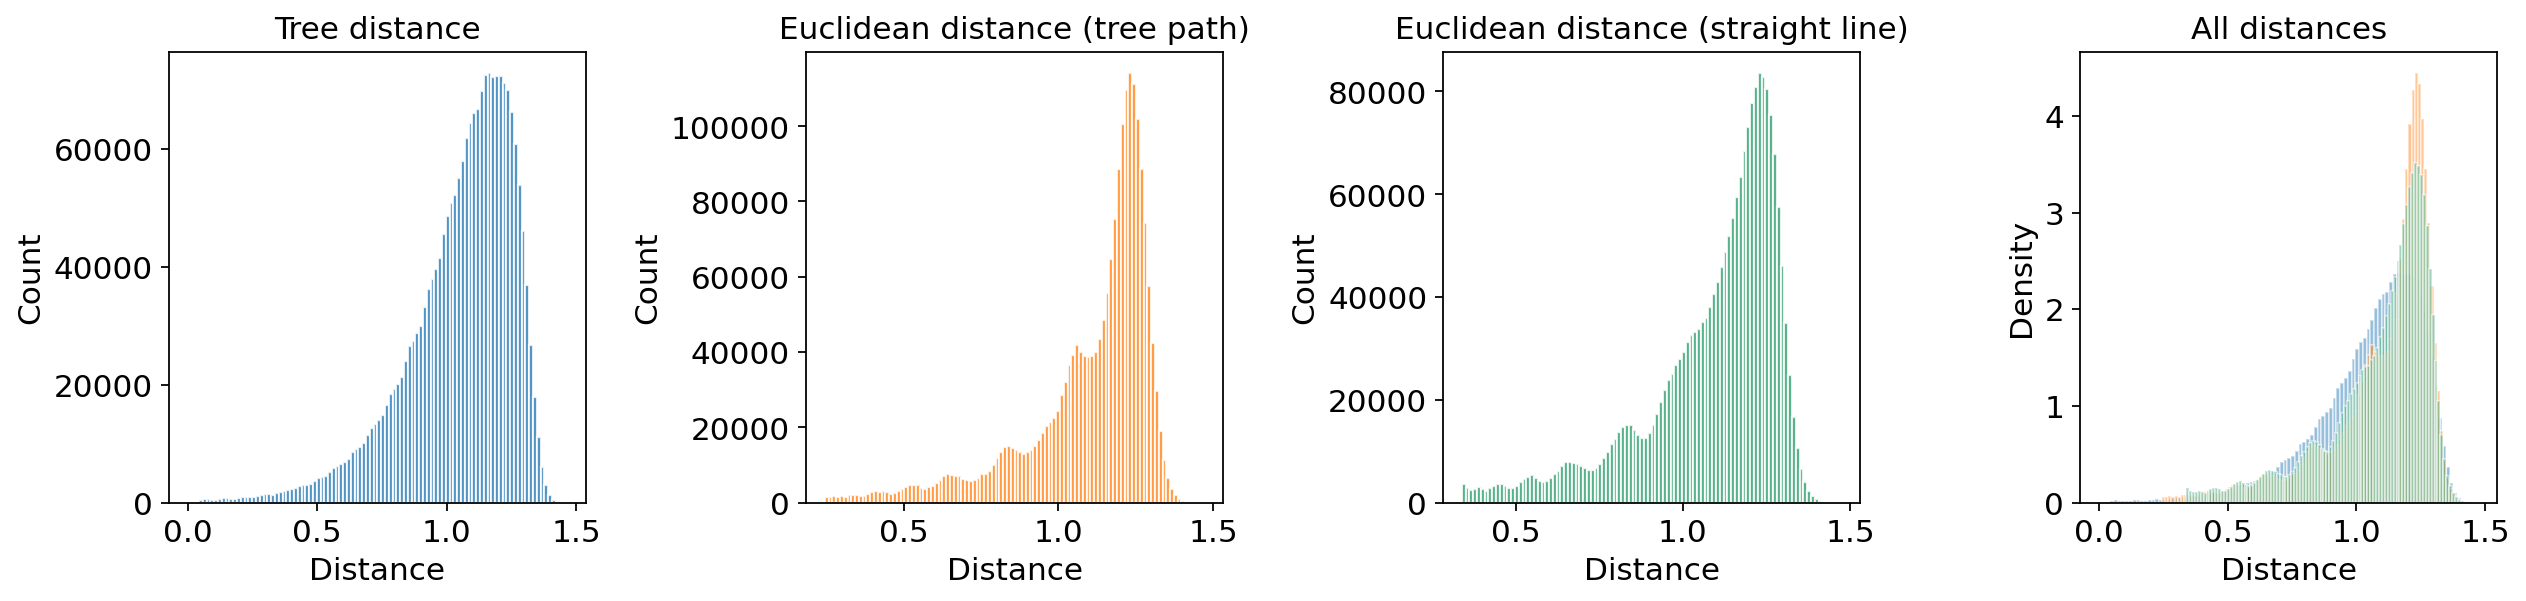

In [95]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].hist(
    squareform(tree_distances), bins=100, color="C0", alpha=0.85, edgecolor="white"
)
axes[0].set_title("Tree distance")
axes[0].set_xlabel("Distance")
axes[0].set_ylabel("Count")
axes[0].grid(False)

axes[1].hist(
    squareform(euclidean_distances_match_tree),
    bins=100,
    color="C1",
    alpha=0.85,
    edgecolor="white",
)
axes[1].set_title("Euclidean distance (tree path)")
axes[1].set_xlabel("Distance")
axes[1].set_ylabel("Count")
axes[1].grid(False)

axes[2].hist(
    squareform(euclidean_distances_match),
    bins=100,
    color="C2",
    alpha=0.85,
    edgecolor="white",
)
axes[2].set_title("Euclidean distance (straight line)")
axes[2].set_xlabel("Distance")
axes[2].set_ylabel("Count")
axes[2].grid(False)

axes[3].hist(
    squareform(tree_distances),
    bins=100,
    color="C0",
    alpha=0.5,
    edgecolor="white",
    density=True,
)
axes[3].hist(
    squareform(euclidean_distances_match_tree),
    bins=100,
    color="C1",
    alpha=0.5,
    edgecolor="white",
    density=True,
)
axes[3].hist(
    squareform(euclidean_distances_match),
    bins=100,
    color="C2",
    alpha=0.5,
    edgecolor="white",
    density=True,
)
axes[3].set_title("All distances")
axes[3].set_xlabel("Distance")
axes[3].set_ylabel("Density")
axes[3].grid(False)

plt.tight_layout()
plt.show()
plt.close()

In [114]:
import matplotlib

with h5py.File("./heemskerk_data/Bonsai_toy/bonsai/bonsai_vis_data.hdf", "r") as f:
    metadata = json.loads(f.attrs["metadata_json"])
cell_ids = metadata["cellIds"]
# cell ids look like Cell0000000000, take first 3 digits as the cell type
cell_type_vec = np.array([cid[4:7] for cid in cell_ids])
clusters = np.unique(cell_type_vec)

node_id_to_vert_ind = {}
with open(bonsai_output_folder / "vertInfo.txt") as f:
    next(f)
    for line in f:
        parts = line.strip().split("\t")
        node_id_to_vert_ind[parts[2]] = int(parts[0])

G = nx.Graph()
with open(bonsai_output_folder / "edgeInfo.txt") as f:
    for line in f:
        v1, v2, d = line.strip().split("\t")
        G.add_edge(int(v1), int(v2), weight=np.sqrt(float(d)))

order_row = True
cell_vert_inds = [node_id_to_vert_ind[cid] for cid in cell_ids]

root_id = "internal_2"
_tree_t = nx.shortest_path_length(
    G, source=node_id_to_vert_ind[root_id], weight="weight"
)
dists_to_root = np.array([_tree_t[cvid] for cvid in cell_vert_inds])
dists_to_root_by_cluster = np.zeros(len(cell_ids))

for c in clusters:
    dists_to_root_by_cluster[cell_type_vec == c] = np.mean(
        dists_to_root[cell_type_vec == c]
    )

reorder_ind = np.lexsort((dists_to_root, dists_to_root_by_cluster))

dist_matrix_tree_t_ordered = tree_distances[:, reorder_ind]
dist_matrix_tree_e_ordered = euclidean_distances_match_tree[:, reorder_ind]
dist_matrix_straight_ordered = euclidean_distances_match[:, reorder_ind]
if order_row:
    dist_matrix_tree_t_ordered = dist_matrix_tree_t_ordered[reorder_ind, :]
    dist_matrix_tree_e_ordered = dist_matrix_tree_e_ordered[reorder_ind, :]
    dist_matrix_straight_ordered = dist_matrix_straight_ordered[reorder_ind, :]

window_size = 30
cell_types = clusters
# cell types: 000, 001, 010, 011, 100, 101, 110, 111
colors = matplotlib.colormaps["tab10"].colors
cell_composition_matrix = np.zeros((len(cell_types) + 1, len(cell_ids)))
for i, cell_type in enumerate(cell_types):
    res = np.convolve(
        cell_type_vec[reorder_ind] == cell_type,
        np.ones(window_size),
        mode="valid",
    )
    margin = int(np.ceil((cell_composition_matrix.shape[1] - res.shape[0]) / 2))
    res = np.pad(res, (margin, margin), mode="constant")
    cell_composition_matrix[i, :] = res[: cell_composition_matrix.shape[1]]
cell_composition_matrix[-1, :] = 1
cell_composition_matrix = cell_composition_matrix / np.sum(
    cell_composition_matrix, axis=0
)

In [ ]:
from matplotlib.colors import PowerNorm

FONTSIZE = 15
heatmaps = [
    {
        "mat": dist_matrix_tree_t_ordered,
        "title": "Bonsai tree distance (t)",
        "filename": "bonsai_distance_heatmap_tree_t_toy.png",
        "normalize": True,
        "cmap": "viridis",
        "norm_type": "power",
        "power_gamma": 1.0,
        "sigmoid_scale": 8,
        "vmin": 0.125,
        "vmax": 0.875,
        "cbar_low_label": 0,
        "cbar_high_label": 1.5,
    },
    {
        "mat": dist_matrix_tree_e_ordered,
        "title": "Bonsai tree distance (euclidean)",
        "filename": "bonsai_distance_heatmap_euclidean_tree_matched_toy.png",
        "normalize": True,
        "cmap": "viridis",
        "norm_type": "power",
        "power_gamma": 1.0,
        "sigmoid_scale": 8,
        "vmin": 0.05,
        "vmax": 0.95,
        "cbar_low_label": 0,
        "cbar_high_label": 1.5,
    },
    {
        "mat": dist_matrix_straight_ordered,
        "title": "Embedding euclidean distance",
        "filename": "bonsai_distance_heatmap_euclidean_straight_matched_toy.png",
        "normalize": True,
        "cmap": "viridis",
        "norm_type": "power",
        "power_gamma": 1.0,
        "sigmoid_scale": 8,
        "vmin": 0.05,
        "vmax": 0.95,
        "cbar_low_label": 0,
        "cbar_high_label": 1.5,
    },
    {
        "mat": dist_matrix_tree_e_ordered - dist_matrix_straight_ordered,
        "title": "Bonsai tree distance (euclidean) - Embedding euclidean distance",
        "filename": "bonsai_distance_heatmap_euclidean_difference_toy.png",
        "normalize": False,
        "cmap": "cividis",
        "norm_type": "power",
        "power_gamma": 1.0,
        "sigmoid_scale": 12,
        "vmin": 0,
        "vmax": 1,
        "cbar_low_label": 0,
        "cbar_high_label": 1,
    },
]

for heatmap in heatmaps:
    plot_mat = (heatmap["mat"] + heatmap["mat"].T) / 2
    if heatmap["normalize"]:
        maxval = np.max(plot_mat)
        if maxval == 0:
            maxval = 1
        plot_mat = plot_mat / maxval

    vmin = heatmap["vmin"]
    vmax = heatmap["vmax"]
    if vmin is None:
        vmin = float(np.min(plot_mat))
    if vmax is None:
        vmax = float(np.max(plot_mat))
    if vmin == vmax:
        vmax = vmin + 1

    if heatmap["norm_type"] == "power":
        norm = PowerNorm(gamma=heatmap["power_gamma"], vmin=vmin, vmax=vmax)
    elif heatmap["norm_type"] == "sigmoid":
        norm = SigmoidNorm(vmin=vmin, vmax=vmax, scale=heatmap["sigmoid_scale"])
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)

    low_label = heatmap["cbar_low_label"]
    high_label = heatmap["cbar_high_label"]
    if low_label is None:
        low_label = f"{vmin:.2f}"
    if high_label is None:
        high_label = f"{vmax:.2f}"

    if vmin < 0 < vmax:
        cbar_ticks = [vmin, 0.0, vmax]
        cbar_ticklabels = [low_label, "0", high_label]
    else:
        cbar_ticks = [vmin, vmax]
        cbar_ticklabels = [low_label, high_label]
    cbar_label = "Distance value" if heatmap["normalize"] else "Difference value"

    g = sns.clustermap(
        plot_mat,
        cmap=heatmap["cmap"],
        cbar=True,
        square=False,
        xticklabels=False,
        yticklabels=False,
        row_cluster=False,
        col_cluster=False,
        figsize=(10, 10),
        rasterized=True,
        norm=norm,
    )
    ax_hm = g.ax_heatmap
    ax_hm.set_aspect("equal")
    g.ax_row_dendrogram.set_visible(False)
    g.ax_col_dendrogram.set_visible(False)
    g.cax.set_visible(False)

    ax_hm.set_position([0.1, 0.08, 0.78, 0.78])
    pos = ax_hm.get_position()

    n = plot_mat.shape[1]
    n_rows = plot_mat.shape[0]
    x = np.arange(n)
    y = np.arange(n_rows)

    tick_x = np.arange(0, n, 100)
    tick_x_labels = [str(int(t)) if t % 500 == 0 else "" for t in tick_x]
    ax_hm.set_xticks(tick_x)
    ax_hm.set_xticklabels(tick_x_labels, fontsize=FONTSIZE)
    ax_hm.tick_params(axis="x", which="major", length=3, direction="out")
    ax_hm.grid(False)

    tick_y = np.arange(0, n_rows, 100)
    tick_y_labels = [str(int(t)) if t % 500 == 0 else "" for t in tick_y]
    ax_hm.set_yticks(tick_y)
    ax_hm.set_yticklabels(tick_y_labels, fontsize=FONTSIZE)
    ax_hm.tick_params(axis="y", which="major", length=3, direction="out")
    ax_hm.set_xlabel(
        "Cells (ranked by Bonsai distance to pluripotent root)", fontsize=FONTSIZE
    )
    ax_hm.set_ylabel(
        "Cells (ranked by Bonsai distance to pluripotent root)", fontsize=FONTSIZE
    )

    ax_top = g.fig.add_axes([pos.x0, pos.y1 + 0.01, pos.width, 0.05])
    ax_top.stackplot(
        x, cell_composition_matrix[:-1, :], labels=cell_types, colors=colors
    )
    ax_top.set_xlim(ax_hm.get_xlim())
    ax_top.axis("off")
    ax_top.text(
        1.01,
        0.5,
        "cell identity",
        transform=ax_top.transAxes,
        ha="left",
        va="center",
        rotation=0,
        fontsize=FONTSIZE,
        clip_on=False,
    )

    ax_left = g.fig.add_axes([pos.x0 - 0.06, pos.y0, 0.05, pos.height])
    cumulative = np.cumsum(cell_composition_matrix[:-1, :], axis=0)
    prev = np.zeros(n_rows)
    for i in range(cumulative.shape[0]):
        ax_left.fill_betweenx(y, prev, cumulative[i], color=colors[i])
        prev = cumulative[i]
    ax_left.set_xlim(1, 0)
    ax_left.set_ylim(ax_hm.get_ylim())
    ax_left.axis("off")

    ax_top.set_title(heatmap["title"], fontsize=FONTSIZE * 1.5)

    mappable = ScalarMappable(norm=norm, cmap=heatmap["cmap"])
    mappable.set_array([])
    cax = g.fig.add_axes([pos.x0 - 0.03, 1.01, 0.1, 0.018])
    cb = g.fig.colorbar(mappable, cax=cax, orientation="horizontal")
    cb.set_ticks(cbar_ticks)
    cb.set_ticklabels(cbar_ticklabels)
    cb.set_label(cbar_label, fontsize=FONTSIZE, labelpad=4)
    cb.ax.tick_params(labelsize=FONTSIZE)

    plt.savefig(heatmap["filename"], dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

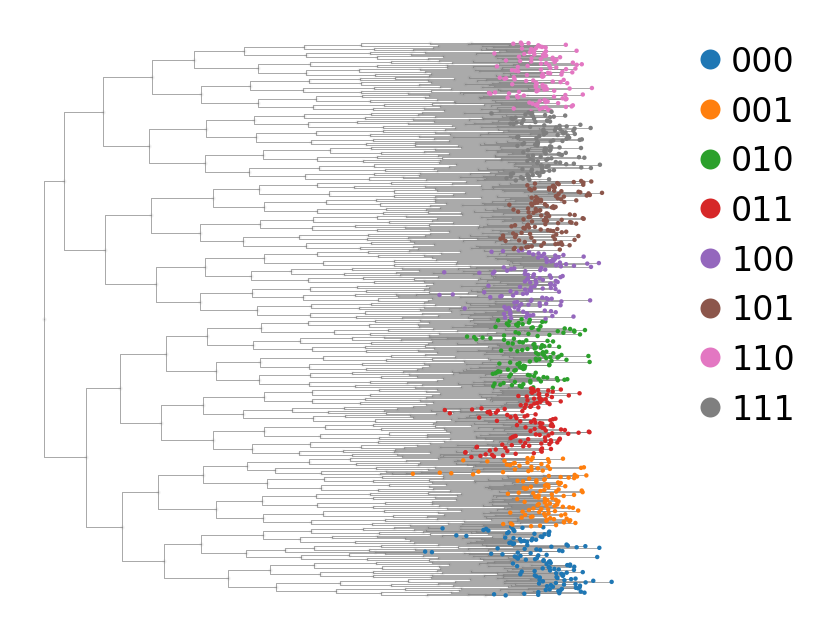

In [129]:
from matplotlib.lines import Line2D

f = h5py.File("./heemskerk_data/Bonsai_toy/bonsai/bonsai_vis_data.hdf", "r")
categories = clusters
cat_to_color = dict(zip(clusters, colors[: len(clusters)]))
cell_colors = [cat_to_color[c] for c in cell_type_vec]

coords_d = f["layout_coords/node_coords/ly_dendrogram_ladderized"][:]
edge_coords_d = f["layout_coords/edge_coords/ly_dendrogram_ladderized"][:]
vert_to_cell = json.loads(f["vert_info"].attrs["vert_ind_to_cell_inds_json"])
int_inds = f["tree_info/int_inds"][:]
cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(
    coords_d[int_inds, 0], coords_d[int_inds, 1], s=1, c="gray", alpha=0.1, zorder=2
)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
ax.set_aspect("auto")


handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=cat_to_color[c],
        markersize=10,
        label=c,
    )
    for c in categories
]
ax.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")
plt.savefig("bonsai_toy_dendrogram.png", dpi=300, bbox_inches="tight")
f.close()